# 06 - Preliminary Results for the First Review

This notebook **collects** the untuned results of notebooks 02-05 into the tables and figures for the review.
The only new computations are (a) a *random-split* reference for all seven models and (b) the confusion matrices of the best model.

> **Reminder - how to read the numbers**
> * Every model uses scikit-learn **default settings**; nothing is tuned. Pipelines: `raw` = scaling only, `PCA` = 95% variance, `LDA` = 5 axes.
> * **P1** = train on batches 1-3, test on each of 4-10 (our headline); **P2** = train on batch 1 only; **P3** = rolling retraining.
> * Scores are **averaged over test batches** (each batch counts equally). Several batches are small, so differences of a few points are within noise.
> * Rankings are *descriptive*. Choosing a final model by test-batch scores would be tuning on the test set, so the final model will be chosen with validation inside the training batches.

In [1]:
import os, sys, warnings
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "16"); warnings.filterwarnings("ignore")
from pathlib import Path
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from src.data import load_all, GAS_NAMES
from src.models import default_models
from src.evaluate import evaluate_protocol, GAS_LABELS
from src.plotting import apply_style, INK, INK2, GRID, SERIES, MARKERS, SEQ, DIV
apply_style()
FIG = ROOT / "results" / "figures"; RES = ROOT / "results"

res = pd.concat([pd.read_csv(RES / "04_baselines_results.csv"), pd.read_csv(RES / "05_stacking_results.csv")], ignore_index=True)
rand = pd.read_csv(RES / "06_random_split_baselines.csv")
BASE = list(default_models())
print("rows:", len(res), "| models:", res.model.nunique(), "| protocols:", sorted(res.protocol.unique()))

rows: 646 | models: 10 | protocols: ['P1', 'P2', 'P3']


## 1. Master tables

For each model and feature pipeline: mean **accuracy**, macro-**precision**, macro-**recall**, macro-**F1** over the test batches, plus the
sample-weighted macro-F1 (each *sample* counts equally, so the big batches 6, 7 and 10 dominate).

In [2]:
def master(proto):
    d = res[res.protocol == proto]
    def agg(g):
        w = g["n_test"].to_numpy()
        return pd.Series({"accuracy": g.accuracy.mean(), "macro_precision": g.macro_precision.mean(), "macro_recall": g.macro_recall.mean(),
                          "macro_f1": g.macro_f1.mean(), "weighted_macro_f1": np.average(g.macro_f1, weights=w), "worst_batch_f1": g.macro_f1.min()})
    t = d.groupby(["model", "variant"]).apply(agg, include_groups=False).reset_index().sort_values("macro_f1", ascending=False)
    t.insert(0, "rank", range(1, len(t) + 1)); return t.reset_index(drop=True)

tables = {p: master(p) for p in ["P1", "P2", "P3"]}
for p, t in tables.items(): t.to_csv(RES / f"06_master_table_{p}.csv", index=False)
print("P1 (train B1-3): top 12 of", len(tables["P1"]), "model/pipeline combinations")
display((tables["P1"].head(12).set_index("rank")).round(3))

P1 (train B1-3): top 12 of 28 model/pipeline combinations


,model,variant,accuracy,macro_precision,macro_recall,macro_f1,weighted_macro_f1,worst_batch_f1
rank,,,,,,,,
1,SVM,raw,0.705,0.719,0.737,0.690,0.579,0.431
2,Stacking (random CV),PCA,0.708,0.683,0.717,0.673,0.583,0.509
3,SVM,PCA,0.666,0.691,0.709,0.660,0.552,0.450
4,Stacking (random CV),raw,0.688,0.670,0.693,0.640,0.556,0.420
5,Random Forest,LDA,0.647,0.712,0.666,0.625,0.551,0.284
6,Naive Bayes,LDA,0.632,0.696,0.655,0.621,0.597,0.264
7,SVM,LDA,0.666,0.683,0.675,0.614,0.556,0.404
8,Stacking (random CV),LDA,0.650,0.667,0.662,0.614,0.555,0.388
9,kNN,LDA,0.640,0.671,0.656,0.610,0.532,0.349


In [3]:
floor = tables["P1"][tables["P1"].model == "Majority class"].iloc[0]
print(f"No-skill floor (always predict the most common gas), P1: accuracy {floor.accuracy:.3f}, macro-F1 {floor.macro_f1:.3f}")
best = (tables["P1"][tables["P1"].model != "Majority class"].sort_values("macro_f1", ascending=False).groupby("model").head(1)
        .set_index("model")[["variant", "accuracy", "macro_precision", "macro_recall", "macro_f1"]])
print("\nBest pipeline per model, P1 (descriptive):"); display(best.round(3))
best.to_csv(RES / "06_best_pipeline_per_model_P1.csv")

No-skill floor (always predict the most common gas), P1: accuracy 0.184, macro-F1 0.055

Best pipeline per model, P1 (descriptive):


,variant,accuracy,macro_precision,macro_recall,macro_f1
model,,,,,
SVM,raw,0.705,0.719,0.737,0.690
Stacking (random CV),PCA,0.708,0.683,0.717,0.673
Random Forest,LDA,0.647,0.712,0.666,0.625
Naive Bayes,LDA,0.632,0.696,0.655,0.621
kNN,LDA,0.640,0.671,0.656,0.610
Stacking (batch CV),LDA,0.620,0.649,0.640,0.600
AdaBoost,PCA,0.657,0.634,0.647,0.594
Gradient Boosting,PCA,0.624,0.640,0.629,0.570
Decision Tree,LDA,0.593,0.629,0.609,0.567


## 2. The central picture: a random split overstates performance

For every model (scaling only) we compare the macro-F1 from a **random 70/30 split** (what a naive project would report) with the macro-F1
from the **time-aware protocol P1**. The gap is performance that exists only because near-identical samples sit in both the training and test sets.

,random split,time-aware (P1),gap
model,,,
Decision Tree,0.970,0.408,0.562
Naive Bayes,0.561,0.461,0.099
AdaBoost,0.703,0.488,0.215
Gradient Boosting,0.993,0.495,0.498
Random Forest,0.995,0.518,0.477
kNN,0.990,0.609,0.381
SVM,0.976,0.690,0.286


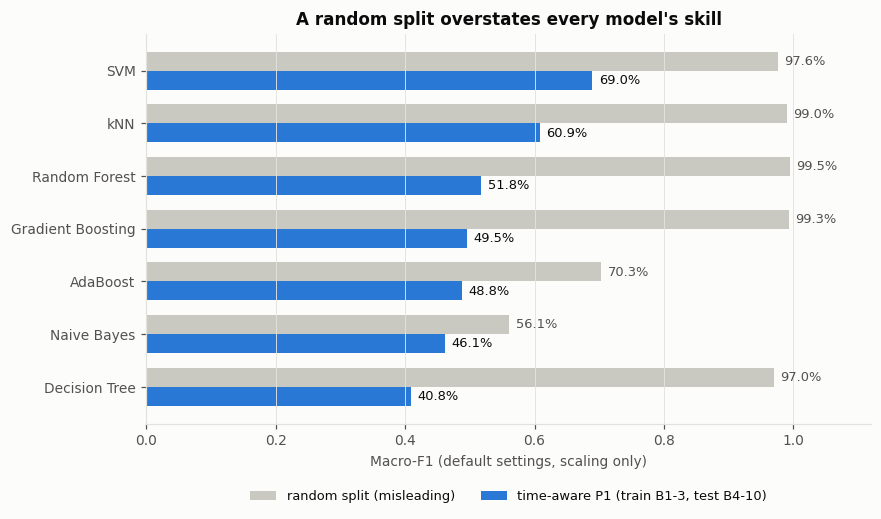

In [4]:
r = rand.set_index("model").macro_f1; t = tables["P1"]; t = t[t.variant == "raw"].set_index("model").macro_f1
cmp = pd.DataFrame({"random split": r, "time-aware (P1)": t}).loc[BASE]
cmp["gap"] = cmp["random split"] - cmp["time-aware (P1)"]; cmp = cmp.sort_values("time-aware (P1)")
cmp.to_csv(RES / "06_random_vs_timeaware.csv"); display(cmp.round(3))

fig, ax = plt.subplots(figsize=(8.5, 4.6)); ys = np.arange(len(cmp)); h = 0.36
ax.barh(ys + h / 2, cmp["random split"], h, color="#c9c8c1", label="random split (misleading)")
ax.barh(ys - h / 2, cmp["time-aware (P1)"], h, color=SERIES[0], label="time-aware P1 (train B1-3, test B4-10)")
for i, (a, b_) in enumerate(zip(cmp["random split"], cmp["time-aware (P1)"])):
    ax.text(a + 0.01, i + h / 2, f"{a:.1%}", va="center", fontsize=8.5, color=INK2); ax.text(b_ + 0.01, i - h / 2, f"{b_:.1%}", va="center", fontsize=8.5)
ax.set_yticks(ys); ax.set_yticklabels(cmp.index); ax.set_xlim(0, 1.12); ax.set_xlabel("Macro-F1 (default settings, scaling only)"); ax.grid(axis="y", visible=False)
ax.set_title("A random split overstates every model's skill"); ax.legend(frameon=False, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2)
fig.savefig(FIG / "21_random_vs_timeaware.png"); plt.show()

## 3. Performance degradation over time (P1)

Per-batch macro-F1 of the four best models, each with its best pipeline (by mean macro-F1 on P1) and the no-skill floor. Batches further from the
training period (4-5 are closest; 8-10 are farthest) are harder, with batch 10 the lowest for several models.

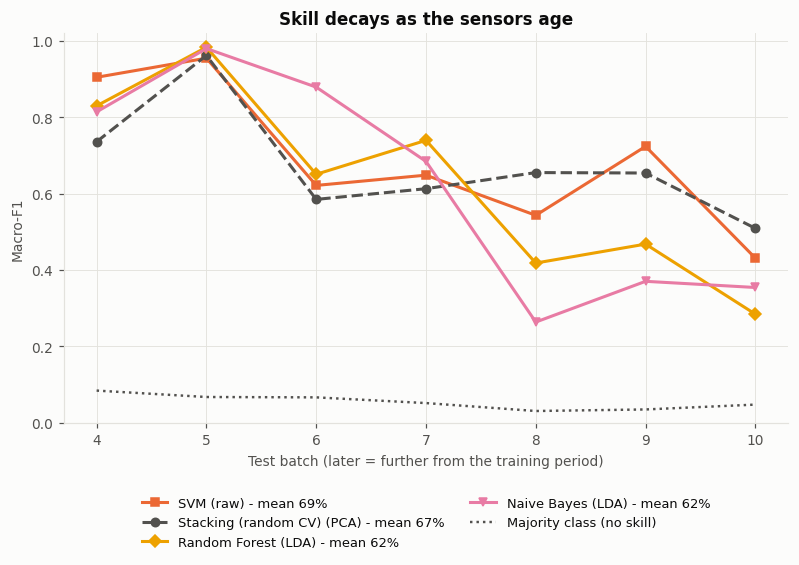

accuracy        macro_f1       
model           SVM    kNN      SVM    kNN
test_batch                                
4             0.876  0.727    0.905  0.755
5             0.954  0.756    0.955  0.796
6             0.697  0.630    0.621  0.587
7             0.684  0.621    0.648  0.591
8             0.551  0.449    0.543  0.464
9             0.743  0.621    0.724  0.579
10            0.431  0.499    0.431  0.489

In [5]:
top = best.reset_index().sort_values("macro_f1", ascending=False).head(4)      # best pipeline of the four best models
ent_color = {m: SERIES[i] for i, m in enumerate(BASE)}; ent_color.update({"Stacking (batch CV)": INK, "Stacking (random CV)": INK2})
fig, ax = plt.subplots(figsize=(8.5, 4.6))
for _, row in top.iterrows():
    d = res[(res.protocol == "P1") & (res.model == row.model) & (res.variant == row.variant)]
    ls = "--" if "random CV" in row.model else "-"
    ax.plot(d.test_batch, d.macro_f1, color=ent_color[row.model], ls=ls, marker=MARKERS[BASE.index(row.model)] if row.model in BASE else "o", ms=5.5, lw=2,
            label=f"{row.model} ({row.variant}) - mean {row.macro_f1:.0%}")
d = res[(res.protocol == "P1") & (res.model == "Majority class")]
ax.plot(d.test_batch, d.macro_f1, color=INK2, ls=":", lw=1.6, label="Majority class (no skill)")
ax.set_xlabel("Test batch (later = further from the training period)"); ax.set_ylabel("Macro-F1"); ax.set_ylim(0, 1.02); ax.set_xticks(range(4, 11))
ax.set_title("Skill decays as the sensors age"); ax.legend(frameon=False, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)
fig.savefig(FIG / "22_degradation_top_models.png"); plt.show()

pb = res[(res.protocol == "P1") & (res.model.isin(["SVM", "kNN"])) & (res.variant == "raw")].pivot(index="test_batch", columns="model", values=["accuracy", "macro_f1"]).round(3)
pb.to_csv(RES / "06_per_batch_P1_svm_knn.csv"); display(pb)

## 4. Do PCA and LDA help? It depends on the model and the protocol

Each bar is the **change in mean macro-F1** relative to the same model with scaling only (`raw`): positive = the reduction helped, negative = it hurt.

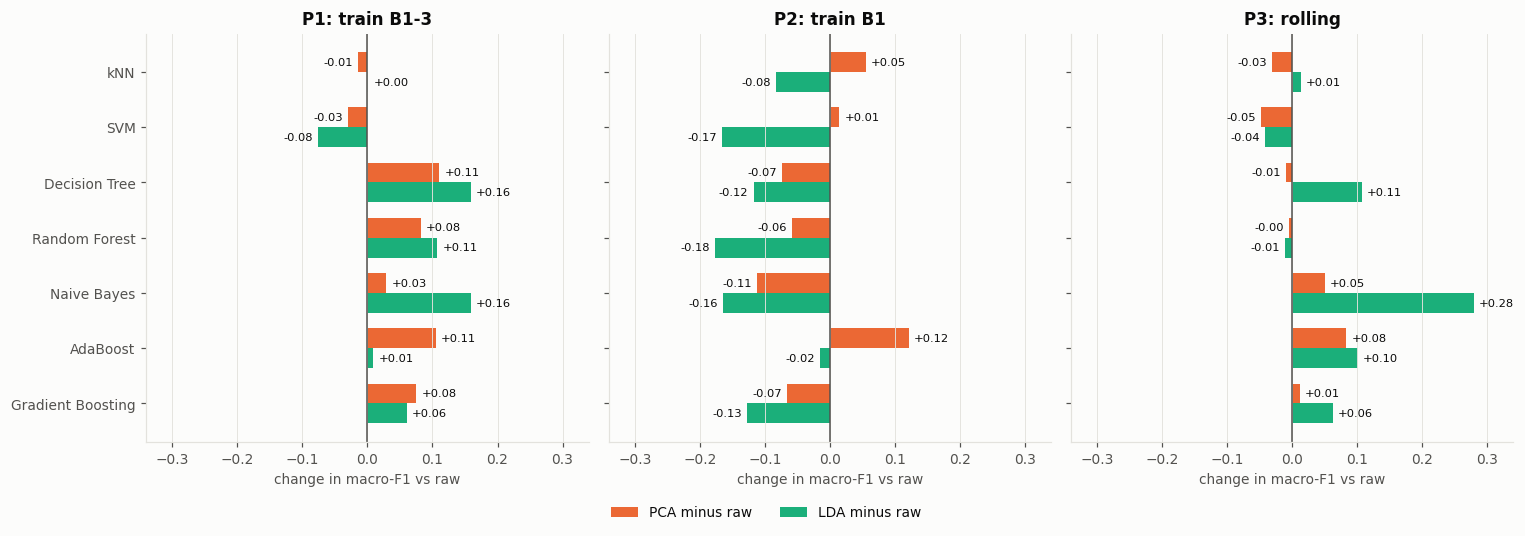

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharey=True)
for ax, p in zip(axes, ["P1", "P2", "P3"]):
    t = tables[p]; piv = t[t.model.isin(BASE)].pivot(index="model", columns="variant", values="macro_f1").loc[BASE[::-1]]
    d = pd.DataFrame({"PCA": piv["PCA"] - piv["raw"], "LDA": piv["LDA"] - piv["raw"]}); ys = np.arange(len(d)); h = 0.36
    ax.barh(ys + h / 2, d["PCA"], h, color=SERIES[1], label="PCA minus raw"); ax.barh(ys - h / 2, d["LDA"], h, color=SERIES[2], label="LDA minus raw")
    for i, (a, b_) in enumerate(zip(d["PCA"], d["LDA"])):
        ax.text(a + (0.008 if a >= 0 else -0.008), i + h / 2, f"{a:+.2f}", va="center", ha="left" if a >= 0 else "right", fontsize=7.5)
        ax.text(b_ + (0.008 if b_ >= 0 else -0.008), i - h / 2, f"{b_:+.2f}", va="center", ha="left" if b_ >= 0 else "right", fontsize=7.5)
    ax.axvline(0, color=INK2, lw=1); ax.set_yticks(ys); ax.set_yticklabels(d.index); ax.set_xlim(-0.34, 0.34); ax.grid(axis="y", visible=False)
    ax.set_title({"P1": "P1: train B1-3", "P2": "P2: train B1", "P3": "P3: rolling"}[p]); ax.set_xlabel("change in macro-F1 vs raw")
h, l = axes[0].get_legend_handles_labels(); fig.legend(h, l, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.06))
fig.tight_layout(); fig.savefig(FIG / "23_pca_lda_effect.png"); plt.show()

## 5. What does the best model get wrong? (SVM, scaling only, P1)

Confusion matrices show, for each true gas (rows), which gas the model predicted (columns). The diagonal is correct. We show a near batch (4), a middle batch (7)
and the farthest/largest batch (10). Numbers are sample counts; shading is the row-wise share.

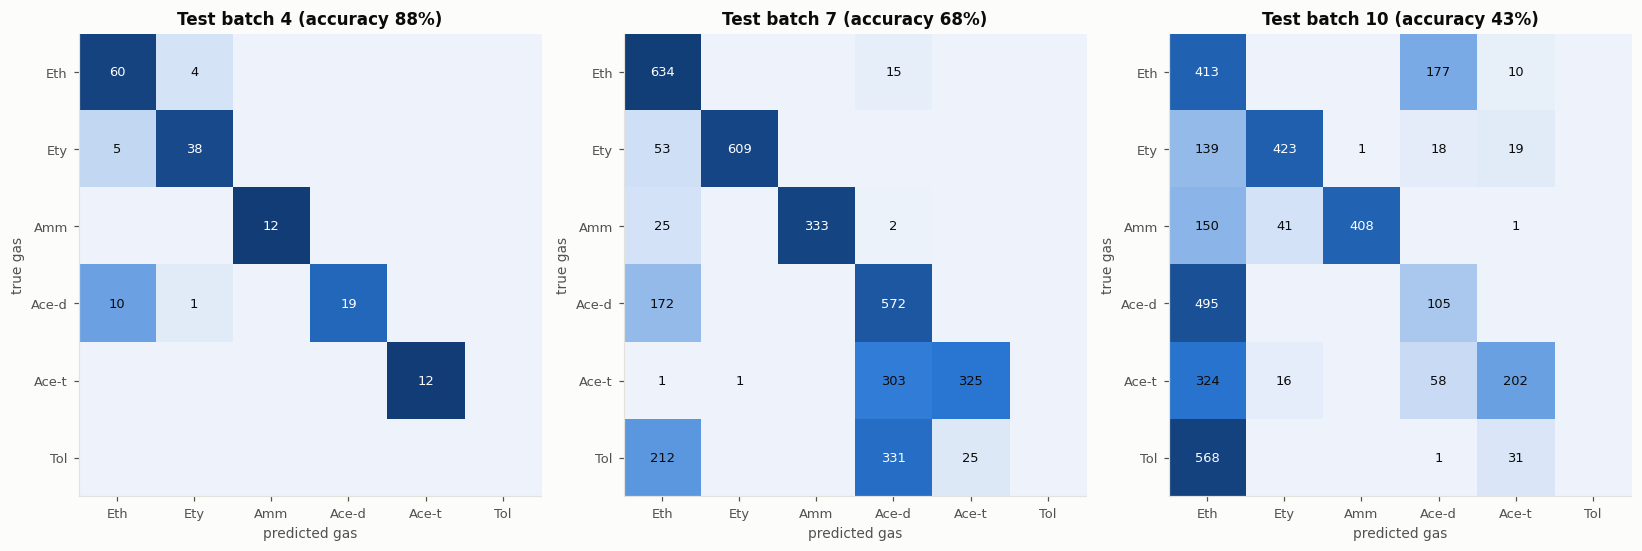

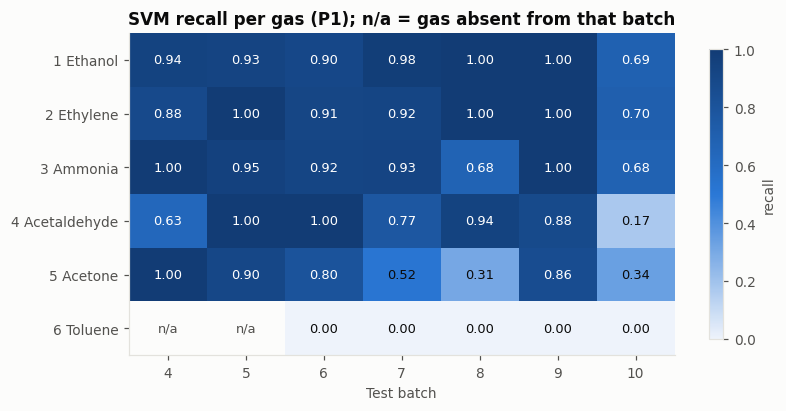

,4,5,6,7,8,9,10
1 Ethanol,0.94,0.93,0.90,0.98,1.00,1.00,0.69
2 Ethylene,0.88,1.00,0.91,0.92,1.00,1.00,0.70
3 Ammonia,1.00,0.95,0.92,0.92,0.68,1.00,0.68
4 Acetaldehyde,0.63,1.00,1.00,0.77,0.94,0.88,0.18
5 Acetone,1.00,0.90,0.80,0.52,0.31,0.86,0.34
6 Toluene,NaN,NaN,0.00,0.00,0.00,0.00,0.00


In [7]:
X, y, batch = load_all()
_, cms = evaluate_protocol(SVC(), X, y, batch, "P1", "raw", name="SVM", return_confusion=True)
short = ["Eth", "Ety", "Amm", "Ace-d", "Ace-t", "Tol"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.9))
for ax, tb in zip(axes, [4, 7, 10]):
    cm = cms[tb]; rn = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    ax.imshow(rn, cmap=SEQ, vmin=0, vmax=1); ax.grid(False)
    for a in range(6):
        for b_ in range(6):
            if cm[a, b_]: ax.text(b_, a, cm[a, b_], ha="center", va="center", fontsize=8.5, color="white" if rn[a, b_] > 0.55 else INK)
    acc = np.trace(cm) / cm.sum()
    ax.set_xticks(range(6)); ax.set_xticklabels(short, fontsize=8.5); ax.set_yticks(range(6)); ax.set_yticklabels(short, fontsize=8.5)
    ax.set_title(f"Test batch {tb} (accuracy {acc:.0%})"); ax.set_xlabel("predicted gas"); ax.set_ylabel("true gas")
fig.tight_layout(); fig.savefig(FIG / "24_confusion_svm.png"); plt.show()

recall = pd.DataFrame({tb: np.where(cms[tb].sum(axis=1) > 0, np.diag(cms[tb]) / np.maximum(cms[tb].sum(axis=1), 1), np.nan) for tb in range(4, 11)},
                      index=[f"{g} {GAS_NAMES[g]}" for g in GAS_LABELS])
recall.to_csv(RES / "06_svm_per_gas_recall_P1.csv")
fig, ax = plt.subplots(figsize=(8, 3.8)); m = np.ma.masked_invalid(recall.values)
im = ax.imshow(m, cmap=SEQ, vmin=0, vmax=1, aspect="auto"); ax.grid(False)
ax.set_xticks(range(7)); ax.set_xticklabels(range(4, 11)); ax.set_yticks(range(6)); ax.set_yticklabels(recall.index)
for i in range(6):
    for j in range(7):
        v = recall.values[i, j]; ax.text(j, i, "n/a" if np.isnan(v) else f"{v:.2f}", ha="center", va="center", fontsize=8.5, color=INK2 if np.isnan(v) else ("white" if v > 0.55 else INK))
ax.set_xlabel("Test batch"); ax.set_title("SVM recall per gas (P1); n/a = gas absent from that batch")
fig.colorbar(im, ax=ax, label="recall", shrink=0.9); fig.savefig(FIG / "25_svm_per_gas_recall.png"); plt.show()
display(recall.round(2))

## 6. A hidden factor: Toluene is almost never in the training data

The per-gas recall table above shows **Toluene recall of 0.00 on every later batch**. Toluene is only 79 of the 3,275 training samples (2.4%), and 74 of
them come from batch 1, the oldest. Later batches contain 18 to 600 Toluene samples. So the P1 setup asks the models to recognise a gas they have barely seen,
and only in its oldest form. This is partly a *data-scarcity* effect and partly *drift*; the tests below separate what they can.

For six fast models (scaling only, P1) we measure: Toluene recall, how often the model predicts Toluene at all, macro-F1 over all six gases, macro-F1 over
gases 1-5 only (Toluene removed from the average; its errors still count against the other gases), and accuracy on the non-Toluene samples.

In [8]:
from sklearn.base import clone
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
trm = batch <= 3
Zt = StandardScaler().fit(X[trm]).transform(X)
print("Toluene in training batches 1-3:", int((y[trm] == 6).sum()), "of", int(trm.sum()), f"({(y[trm] == 6).mean():.1%}) | per test batch:",
      {k: int(((batch == k) & (y == 6)).sum()) for k in range(4, 11)})
rows = []
for n in ["SVM", "kNN", "Random Forest", "Naive Bayes", "Decision Tree", "AdaBoost"]:
    m = clone(default_models()[n]).fit(Zt[trm], y[trm])
    for tb in range(4, 11):
        te = batch == tb; p = m.predict(Zt[te]); yt = y[te]; tol = yt == 6
        rows.append({"model": n, "batch": tb, "n_toluene": int(tol.sum()), "toluene_recall": (p[tol] == 6).mean() if tol.any() else np.nan,
                     "times_predicts_toluene": int((p == 6).sum()),
                     "macro_f1_all6": f1_score(yt, p, labels=np.unique(yt), average="macro", zero_division=0),
                     "macro_f1_gases1to5": f1_score(yt, p, labels=[1, 2, 3, 4, 5], average="macro", zero_division=0),
                     "acc_non_toluene": (p[~tol] == yt[~tol]).mean()})
tol_df = pd.DataFrame(rows); tol_df.to_csv(RES / "06_toluene_diagnostic.csv", index=False)
print("\nToluene recall (batches that contain Toluene):"); display(tol_df[tol_df.n_toluene > 0].pivot(index="model", columns="batch", values="toluene_recall").round(2))
print("Number of Toluene predictions the model makes at all (batches 6-10):"); display(tol_df[tol_df.batch >= 6].pivot(index="model", columns="batch", values="times_predicts_toluene"))
print("Mean over batches 4-10 / over batches 6-10 (the ones that contain Toluene):")
display(pd.concat({"B4-10": tol_df.groupby("model")[["macro_f1_all6", "macro_f1_gases1to5", "acc_non_toluene"]].mean(),
                   "B6-10": tol_df[tol_df.batch >= 6].groupby("model")[["macro_f1_all6", "macro_f1_gases1to5", "acc_non_toluene"]].mean()}, axis=1).round(3))
svm = tol_df[tol_df.model == "SVM"].set_index("batch"); print("SVM accuracy on non-Toluene samples by batch:", svm.acc_non_toluene.round(3).to_dict())

Toluene in training batches 1-3: 79 of 3275 (2.4%) | per test batch: {4: 0, 5: 0, 6: 467, 7: 568, 8: 18, 9: 101, 10: 600}


  File "C:\Users\kiran\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\kiran\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\kiran\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\kiran\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^



Toluene recall (batches that contain Toluene):


batch,6,7,8,9,10
model,,,,,
AdaBoost,0.00,0.0,0.0,0.0,0.00
Decision Tree,0.00,0.0,0.0,0.0,0.00
Naive Bayes,0.01,0.0,0.0,0.0,0.12
Random Forest,0.00,0.0,0.0,0.0,0.00
SVM,0.00,0.0,0.0,0.0,0.00
kNN,0.00,0.0,0.0,0.0,0.00


Number of Toluene predictions the model makes at all (batches 6-10):


batch,6,7,8,9,10
model,,,,,
AdaBoost,0,0,68,0,0
Decision Tree,1,1,0,0,0
Naive Bayes,288,19,19,6,160
Random Forest,0,0,0,0,0
SVM,0,0,0,0,0
kNN,0,0,0,0,0


Mean over batches 4-10 / over batches 6-10 (the ones that contain Toluene):


B4-10                                            B6-10  \
              macro_f1_all6 macro_f1_gases1to5 acc_non_toluene macro_f1_all6   
model                                                                          
AdaBoost              0.488              0.540           0.577         0.359   
Decision Tree         0.408              0.452           0.522         0.304   
Naive Bayes           0.461              0.501           0.559         0.315   
Random Forest         0.518              0.577           0.646         0.415   
SVM                   0.690              0.774           0.795         0.594   
kNN                   0.609              0.686           0.697         0.542   

                                                  
              macro_f1_gases1to5 acc_non_toluene  
model                                             
AdaBoost                   0.430           0.483  
Decision Tree              0.364           0.454  
Naive Bayes                0.370           0.451  
Random Forest              0.498           0.584  
SVM                        0.712           0.747  
kNN                        0.650           0.679

SVM accuracy on non-Toluene samples by batch: {4: 0.876, 5: 0.954, 6: 0.875, 7: 0.812, 8: 0.587, 9: 0.946, 10: 0.517}


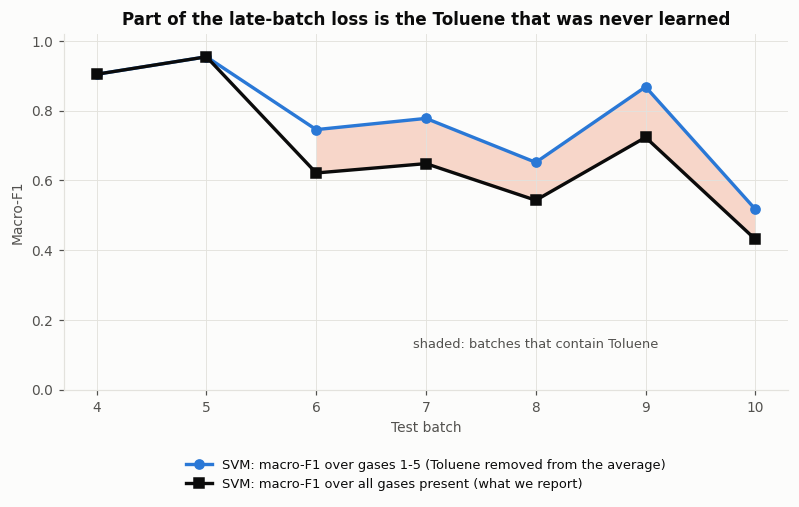

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(svm.index, svm.macro_f1_gases1to5, color=SERIES[0], marker="o", lw=2.2, label="SVM: macro-F1 over gases 1-5 (Toluene removed from the average)")
ax.plot(svm.index, svm.macro_f1_all6, color=INK, marker="s", lw=2.2, label="SVM: macro-F1 over all gases present (what we report)")
ax.fill_between(svm.index, svm.macro_f1_all6, svm.macro_f1_gases1to5, where=svm.n_toluene > 0, color=SERIES[1], alpha=0.25, lw=0)
ax.set_xlabel("Test batch"); ax.set_ylabel("Macro-F1"); ax.set_ylim(0, 1.02); ax.set_xticks(range(4, 11))
ax.set_title("Part of the late-batch loss is the Toluene that was never learned")
ax.legend(frameon=False, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.16))
ax.text(8, 0.12, "shaded: batches that contain Toluene", ha="center", fontsize=8.5, color=INK2)
fig.savefig(FIG / "26_toluene_effect.png"); plt.show()

## 7. Key takeaways for the review

All results are untuned defaults, averaged over test batches. Protocol P1 = train on batches 1-3, test on 4-10.

**Headline table (P1)**

| Rank | Model (pipeline) | Accuracy | Macro-precision | Macro-recall | Macro-F1 |
|---|---|---|---|---|---|
| 1 | **SVM (raw)** | **70.5%** | 71.9% | 73.7% | **69.0%** |
| 2 | Stacking, random-CV meta-learner (PCA) | 70.8% | 68.3% | 71.7% | 67.3% |
| 3 | SVM (PCA) | 66.6% | 69.1% | 70.9% | 66.0% |
| 5 | Random Forest (LDA) | 64.7% | 71.2% | 66.6% | 62.5% |
| 6 | Naive Bayes (LDA) | 63.2% | 69.6% | 65.5% | 62.1% |
| 9 | kNN (LDA) | 64.0% | 67.1% | 65.6% | 61.0% |
| 10 | kNN (raw) | 61.5% | 65.0% | 66.7% | 60.9% |
| 11 | Stacking, leakage-safe batch-CV (LDA, its best) | 62.0% | 64.9% | 64.0% | 60.0% |
| - | *Majority class (no skill)* | *18.4%* | - | - | *5.5%* |

1. **Best preliminary result: SVM with plain scaling, 70.5% accuracy and 69.0% macro-F1 on P1.** The no-skill floor is 18.4% accuracy and 5.5% macro-F1. Under the rolling protocol P3 the top result is again SVM (raw): 82.4% accuracy, 79.7% macro-F1. Under P2 (train on batch 1 only) the top results are Naive Bayes (raw, 41.3% macro-F1) and Random Forest (raw, 41.0%), and nothing exceeds 49% accuracy.
2. **A random split overstates every model.** Macro-F1 from a random 70/30 split vs the time-aware P1 score: SVM 97.6% to 69.0% (-28.6 points), kNN 99.0% to 60.9% (-38.1), Random Forest 99.5% to 51.8% (-47.7), Gradient Boosting 99.3% to 49.5% (-49.8), Decision Tree 97.0% to 40.8% (-56.2), AdaBoost 70.3% to 48.8% (-21.5), Naive Bayes 56.1% to 46.1% (-9.9). Naive Bayes shows a small gap only because it is already poor on a random split.
3. **Skill decays with distance in time, unevenly.** SVM per-gas recall (P1): Ethanol 0.90-1.00 and Ethylene 0.88-1.00 on batches 4-9 but about 0.70 on batch 10; Acetaldehyde 0.63-1.00 on batches 4-9 but 0.18 on batch 10; Acetone 0.31 on batch 8, 0.52 on batch 7 and 0.34 on batch 10.
4. **Toluene is a major hidden factor in the P1 scores.** Toluene is 79 of 3,275 training samples (2.4%), 74 of them from batch 1, and later batches contain 18 to 600 Toluene samples. No model recognises it (recall 0-12%); SVM, kNN and Random Forest never predict Toluene on batches 6-10. Removing Toluene from the average raises SVM's macro-F1 from 69.0% to 77.4% (batches 4-10) and from 59.4% to 71.2% (batches 6-10). **So part of the P1 "drift" penalty is data scarcity for one gas**, which the P1 design cannot separate from drift. Drift is still real: SVM accuracy on the non-Toluene samples is 94.6% on batch 9 but only 58.7% on batch 8 and 51.7% on batch 10.
5. **PCA and LDA have no universal effect.** Change in mean macro-F1 vs scaling only, P1: Decision Tree +0.11 (PCA) / +0.16 (LDA), Random Forest +0.08 / +0.11, Naive Bayes +0.03 / +0.16, AdaBoost +0.11 / +0.01, Gradient Boosting +0.08 / +0.06, but SVM -0.03 / -0.08 and kNN -0.01 / 0.00. Under P2 LDA hurts every model (-0.02 to -0.18). Under P3 LDA helps Naive Bayes (+0.28) and Decision Tree (+0.11) but not SVM (-0.04).
6. **Stacking gave no gain in this preliminary setting** (notebook 05): the leakage-safe version peaks at 60.0% macro-F1 on P1, below SVM.

**What the preliminary results do and do not support**

* Supported: time-aware evaluation changes the conclusion drastically (point 2); sensor drift and the late-period shift hurt all models; distance-based models (SVM, kNN) hold up best; default stacking does not help.
* Not yet supported: any claim that one model is significantly better than another (no confidence intervals or tests yet; several test batches are tiny); any claim about the best PCA/LDA setting (nothing is tuned); any separation of "drift" from "Toluene scarcity" in P1.

**Limitations to state openly:** untuned default settings; single fixed seed; small and imbalanced batches (4, 5, 8); the P1 training set holds almost no Toluene; the dataset copy has no raw baselines, so the Dennler et al. leakage check was indirect.

**Next phase:** tuning with validation inside the training batches, drift-mitigation methods (sliding window, per-batch standardisation, recency weighting), a Toluene-aware evaluation (per-gas reporting and a protocol where Toluene is present in training), significance tests with bootstrap confidence intervals, and a re-designed stacker (forward-chaining folds).